# 示例策略9: 日内回转交易策略

本策略首先买入SHSE.600000股票10000股，随后根据1MIN的数据来计算MACD(12,26,9)线,并在MACD>0的时候买入100股,MACD<0的时候卖出100股。但每日操作的股票数不超过原有仓位,并于收盘前把仓位调整至开盘前的仓位。

回测数据为:SHSE.600000的60s数据

回测时间为:2017-09-01 08:00:00到2017-10-01 16:00:00

In [1]:
import qteasy as qt
import numpy as np
import pandas as pd

In [2]:
class DailyTrading(qt.GeneralStg):
    
    def __init__(self, pars: tuple = (12, 26, 9, 100)):
        super().__init__(
                pars=pars,
                par_count=4,
                par_types=['int', 'int', 'int', 'int'],  # 仓位配置的阈值：参数1:macd-s，参数2: macd-f，参数3：macd-d，参数4:单次交易数量
                par_range=[(5, 50), (5, 50), (5, 50), (100, 500)],
                name='DailyTrading',
                description='日内回转交易策略，根据1分钟MACD线在当日内做T交易，收盘前恢复至10000股',
                strategy_run_timing='close',  # 在1MIN周期结束时运行
                strategy_run_freq='1min',  # 每份钟执行一次调整
                strategy_data_types='close',  # 使用份钟收盘价调整
                data_freq='1min',  # 数据频率（包括股票数据和参考数据）
                window_length=50,
                use_latest_data_cycle=False,  # 高频数据不需要使用当前数据区间
                reference_data_types='cur_time_min',  # 参考数据为当前时间
        )
    
    def realize(self, h, r=None, t=None, pars=None):
        """策略输出VS信号，即数量交易信号"""

        macd_s, macd_f, macd_d, batch = self.pars

        # 读取最近N天的收盘价
        price = h[:, :, 0]  # 最新连续收盘价
        current_time = r[-1: 0]  # 当前交易时间（精确到分钟）

        # 计算MACD
        macd = macd(close, macd_s, macd_f, macd_d)

        # 根据当前的实际价格确定目标仓位，并将目标仓位作为信号输出
        pos = np.zeros_like(close_mean)
        pos = np.where(current_close > hi_positive, hi_pos, pos)
        pos = np.where(hi_positive >= current_close > low_positive, low_pos, pos)
        pos = np.where(low_positive >= current_close > low_negative, 0, pos)
        pos = np.where(low_negative >= current_close > hi_negative, - low_pos, pos)
        pos = np.where(current_close >= hi_negative, - hi_pos, pos)

        return pos


     |                                  |
     |       BACK TESTING RESULT        |
     |                                  |

qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 2 sec 339.3 ms
time consumption for operation back looping:  12 sec 505.8 ms

investment starts on      2022-04-01 09:30:00
ends on                   2022-07-29 15:00:00
Total looped periods:     0.3 years.

-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary

          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000300.SH    42       42     84    0.0%     99.0%      1.0%   

Total operation fee:     ¥   -1,919.41
total investment amount: ¥1,000,000.00
final value:              ¥1,013,449.05
Total return:                      inf% 
Avg Yearly return:                 inf%
Skewness:                          2.69
Kurtosis:                         74.38
Benchmark return:   

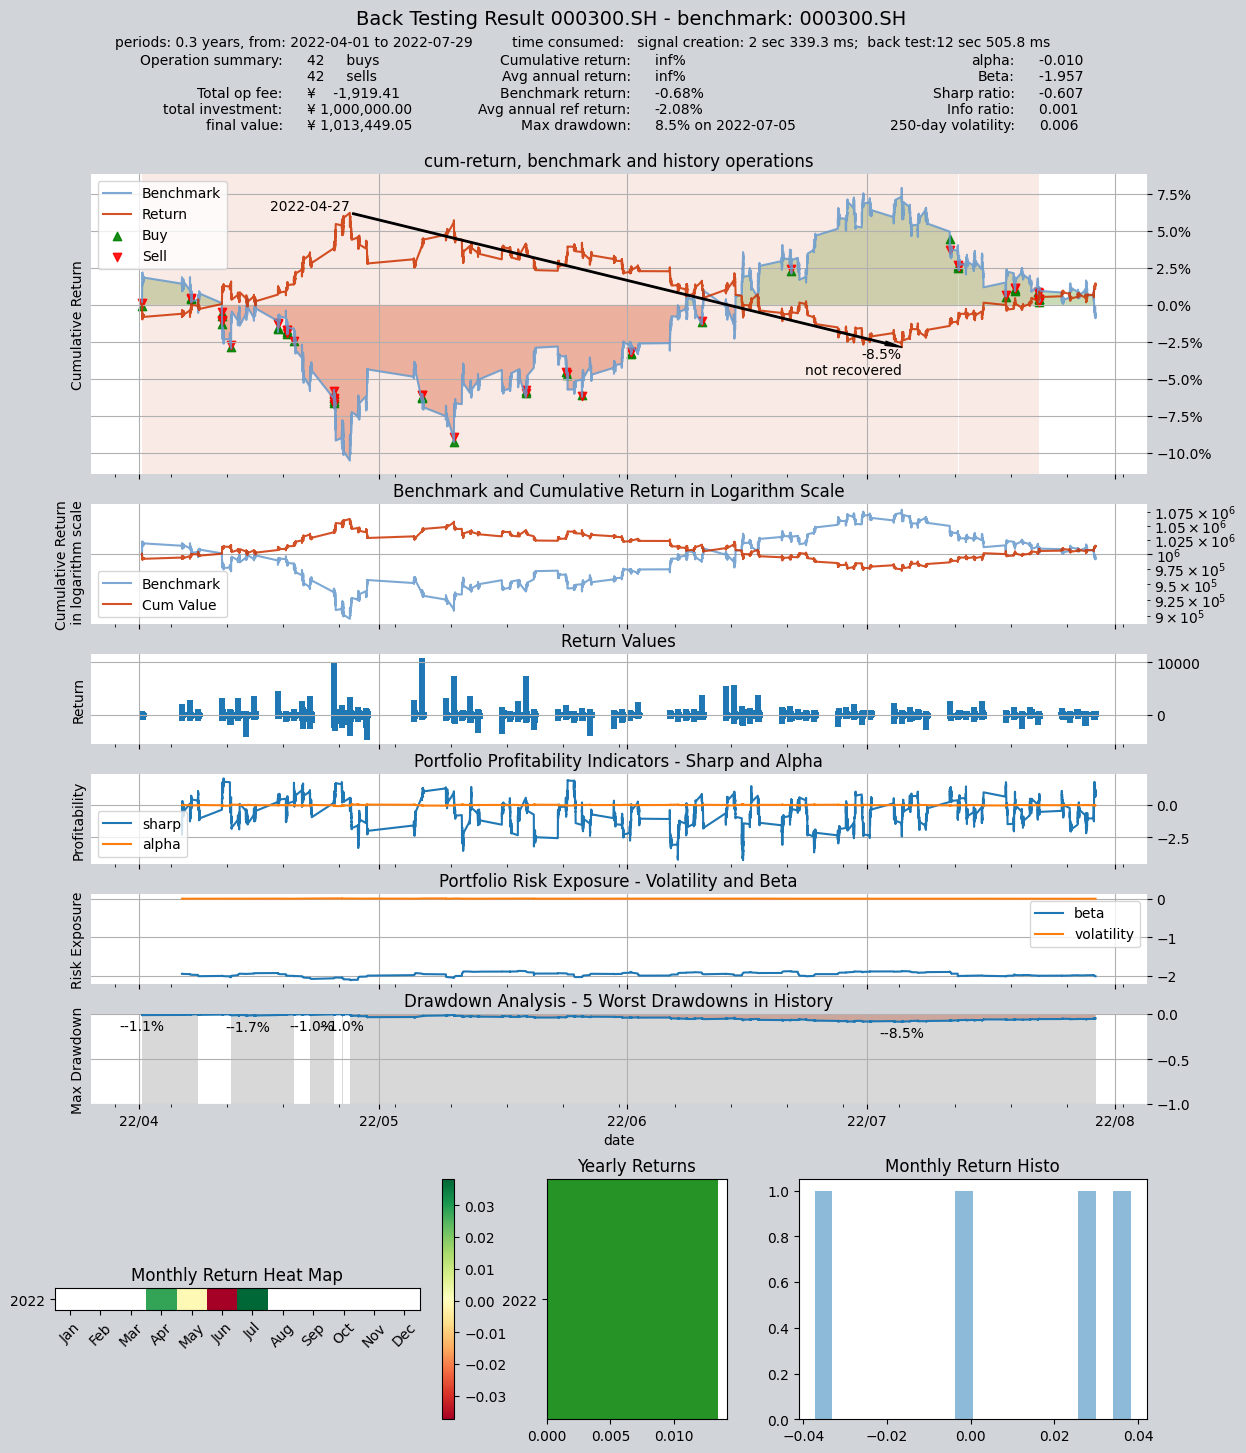

In [3]:
alpha = GridTrading()
op = qt.Operator(alpha, signal_type='PT')
op.op_type = 'batch'
op.set_blender("1.0*s0", 'close')
op.run(
        mode=1,
        invest_start='20220401',
        invest_end='20220731',
        invest_cash_amounts=[1000000],
        asset_type='IDX',
        asset_pool=['000300.SH'],
        trade_batch_size=0,
        sell_batch_size=0,
        trade_log=True,
        allow_sell_short=True,
)

print()

In [6]:
from rich import print as rprint
df = pd.DataFrame({'a': [1,2,3,4,5], 'b':['a', 'b', 'c', 'd', 'e'], 'c': [1., 2., 3., 4., 5.]})
rprint(df)

a  b    c
0  1  a  1.0
1  2  b  2.0
2  3  c  3.0
3  4  d  4.0
4  5  e  5.0